# IBEE — Notebook 03: Anomaly Detection (Isolation Forest)

**Input :** `data/processed/features.csv` (350,400 rows, 27 features)  
**Output:** `data/processed/features_with_anomaly.csv` — adds `anomaly_score` + `is_anomaly`  
**Model :** `models/isolation_forest.pkl`

## Why Isolation Forest here?
- Trained **only on normal rows** (253,942) — no labels needed for training  
- Learns what a healthy hive looks like  
- At inference time: flags any reading that deviates from that baseline  
- The `anomaly_score` column becomes an extra feature in notebook 04 (classifier)  
- In production: fire an alert the moment a reading scores below the threshold  

## Notebook structure
1. Load features  
2. Train/test split (time-aware, stratified)  
3. Train Isolation Forest on normal rows only  
4. Evaluate — detection rate per state, precision/recall  
5. Threshold tuning  
6. Visualisations  
7. Export enriched dataset + model

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import StandardScaler
import pickle

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,
    'figure.dpi':130,'savefig.dpi':150,'savefig.bbox':'tight',
})

DATA_DIR    = Path('../data/processed')
MODELS_DIR  = Path('../models')
REPORTS_DIR = Path('../reports/figures')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

STATE_COLORS = {
    'normal':'#2a9d8f','swarming_risk':'#e9c46a',
    'robbing':'#e76f51','winter_cluster':'#457b9d','empty':'#adb5bd',
}
print('Ready.')

Ready.


## 1. Load features

In [2]:
# Load feature metadata
with open(DATA_DIR / 'features_meta.json') as f:
    meta = json.load(f)

FEATURES = meta['features']
TARGET   = meta['target']

# Load dataset
df = pd.read_csv(DATA_DIR / 'features.csv', parse_dates=['ts'])
df = df.sort_values(['device_id', 'ts']).reset_index(drop=True)

print(f'Shape    : {df.shape}')
print(f'Features : {len(FEATURES)}')
print(f'Classes  : {sorted(df[TARGET].unique())}')
print()
print('Class distribution:')
dist = df[TARGET].value_counts()
for state, n in dist.items():
    print(f'  {state:<20}: {n:>7,}  ({n/len(df)*100:.1f}%)')

Shape    : (350400, 30)
Features : 27
Classes  : ['normal', 'robbing', 'swarming_risk', 'winter_cluster']

Class distribution:
  normal              : 253,942  (72.5%)
  winter_cluster      :  51,974  (14.8%)
  swarming_risk       :  35,566  (10.2%)
  robbing             :   8,918  (2.5%)


## 2. Train / test split
**Time-aware split**: last 20% of timestamps per device → test set.  
This prevents data leakage — the model never sees future readings during training.

In [3]:
# Time-aware split: per device, last 20% → test
train_idx, test_idx = [], []

for dev, grp in df.groupby('device_id'):
    grp   = grp.sort_values('ts')
    n     = len(grp)
    split = int(n * 0.80)
    train_idx.extend(grp.index[:split].tolist())
    test_idx.extend(grp.index[split:].tolist())

df_train = df.loc[train_idx].copy()
df_test  = df.loc[test_idx].copy()

print(f'Train : {len(df_train):,} rows')
print(f'Test  : {len(df_test):,}  rows')
print()
print('Train class distribution:')
print(df_train[TARGET].value_counts().to_string())
print()
print('Test class distribution:')
print(df_test[TARGET].value_counts().to_string())

Train : 280,320 rows
Test  : 70,080  rows

Train class distribution:
hive_state
normal            203401
winter_cluster     41004
swarming_risk      28761
robbing             7154

Test class distribution:
hive_state
normal            50541
winter_cluster    10970
swarming_risk      6805
robbing            1764


## 3. Train Isolation Forest on normal rows only

In [4]:
# Isolation Forest is trained ONLY on normal readings
# contamination = expected fraction of anomalies in real deployment
# We set it to the actual non-normal fraction in the dataset
non_normal_frac = 1 - (df_train[TARGET] == 'normal').mean()
contamination   = round(float(non_normal_frac), 3)
print(f'Contamination parameter: {contamination:.3f}  ({contamination*100:.1f}% of train set is non-normal)')

# Scale features (Isolation Forest is not scale-invariant when used with scoring)
scaler   = StandardScaler()
X_normal = df_train.loc[df_train[TARGET] == 'normal', FEATURES]
X_train  = df_train[FEATURES]
X_test   = df_test[FEATURES]

X_normal_scaled = scaler.fit_transform(X_normal)
X_train_scaled  = scaler.transform(X_train)
X_test_scaled   = scaler.transform(X_test)

print(f'\nNormal train rows: {len(X_normal):,}')
print('Training Isolation Forest...')

iso = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1,
)
iso.fit(X_normal_scaled)
print('Done.')

Contamination parameter: 0.274  (27.4% of train set is non-normal)

Normal train rows: 203,401
Training Isolation Forest...
Done.


## 4. Score & evaluate

In [5]:
# Score the full dataset
df['anomaly_score'] = iso.decision_function(scaler.transform(df[FEATURES]))
df['is_anomaly']    = (iso.predict(scaler.transform(df[FEATURES])) == -1).astype(int)

# Ground truth: 1 = any non-normal state
df['is_anomaly_gt'] = (df[TARGET] != 'normal').astype(int)

# --- Test set evaluation ---
test_mask   = df.index.isin(test_idx)
df_eval     = df[test_mask].copy()

y_true      = df_eval['is_anomaly_gt']
y_pred      = df_eval['is_anomaly']
y_score     = -df_eval['anomaly_score']   # negate: lower score = more anomalous

print('=== Test set: anomaly detection performance ===')
print()
print(classification_report(y_true, y_pred, target_names=['normal','anomaly']))

try:
    roc = roc_auc_score(y_true, y_score)
    ap  = average_precision_score(y_true, y_score)
    print(f'ROC-AUC           : {roc:.4f}')
    print(f'Average Precision : {ap:.4f}')
except Exception as e:
    print(f'ROC/AP error: {e}')

print()
print('=== Detection rate per state (test set) ===')
for state in sorted(df_eval[TARGET].unique()):
    sub  = df_eval[df_eval[TARGET] == state]
    rate = sub['is_anomaly'].mean() * 100
    gt   = 'non-normal' if state != 'normal' else 'normal'
    flag = '✓' if (state != 'normal' and rate > 70) or (state == 'normal' and rate < 30) else '!'
    print(f'  {flag} {state:<20}: {rate:5.1f}% flagged as anomaly  [{gt}]')

=== Test set: anomaly detection performance ===

              precision    recall  f1-score   support

      normal       1.00      0.55      0.71     50541
     anomaly       0.46      1.00      0.63     19539

    accuracy                           0.67     70080
   macro avg       0.73      0.77      0.67     70080
weighted avg       0.85      0.67      0.68     70080

ROC-AUC           : 0.9552
Average Precision : 0.8784

=== Detection rate per state (test set) ===
  ! normal              :  45.5% flagged as anomaly  [normal]
  ✓ robbing             :  99.7% flagged as anomaly  [non-normal]
  ✓ swarming_risk       :  99.6% flagged as anomaly  [non-normal]
  ✓ winter_cluster      :  99.9% flagged as anomaly  [non-normal]


## 5. Threshold tuning
The default threshold (0.0) may not be optimal. We find the threshold that maximises F1 on the test set.

In [6]:
prec, rec, thresholds = precision_recall_curve(y_true, y_score)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_idx  = f1_scores.argmax()
best_thr  = thresholds[best_idx]
best_f1   = f1_scores[best_idx]

print(f'Best threshold (on -anomaly_score): {best_thr:.4f}')
print(f'Best F1 at that threshold         : {best_f1:.4f}')
print(f'Precision                         : {prec[best_idx]:.4f}')
print(f'Recall                            : {rec[best_idx]:.4f}')

# Apply tuned threshold
df['is_anomaly_tuned'] = ((-df['anomaly_score']) >= best_thr).astype(int)

print()
print('=== Detection rate per state (tuned threshold) ===')
for state in sorted(df[TARGET].unique()):
    sub  = df[df[TARGET] == state]
    rate = sub['is_anomaly_tuned'].mean() * 100
    print(f'  {state:<20}: {rate:5.1f}% flagged')

# Save threshold for production use
threshold_config = {
    'anomaly_score_threshold': float(-best_thr),
    'note': 'Flag reading as anomaly when anomaly_score < this value'
}
(MODELS_DIR / 'anomaly_threshold.json').write_text(json.dumps(threshold_config, indent=2))
print(f'\nThreshold saved → models/anomaly_threshold.json')

Best threshold (on -anomaly_score): 0.0425
Best F1 at that threshold         : 0.8209
Precision                         : 0.7637
Recall                            : 0.8873

=== Detection rate per state (tuned threshold) ===
  normal              :   6.9% flagged
  robbing             :  89.7% flagged
  swarming_risk       :  85.1% flagged
  winter_cluster      :  75.6% flagged

Threshold saved → models/anomaly_threshold.json


## 6. Visualisations

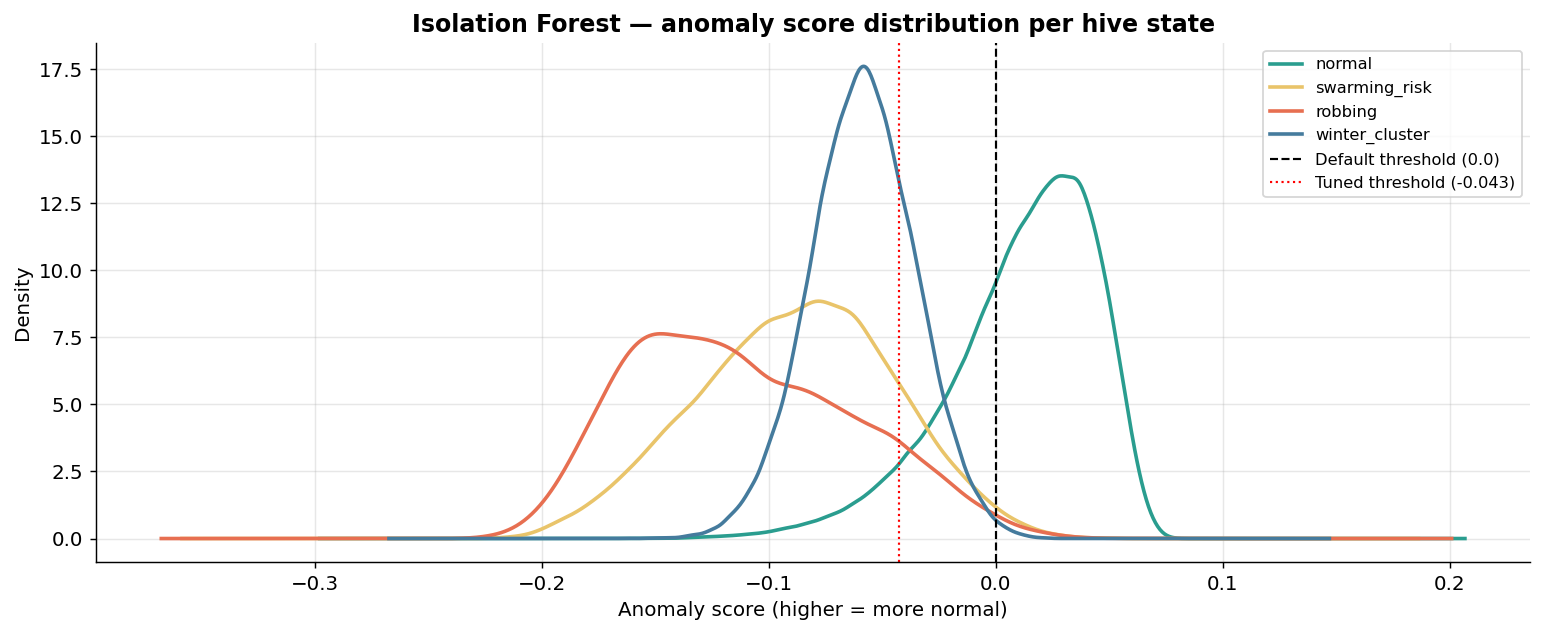

In [7]:
# Figure 1 — Anomaly score distributions per state
fig, ax = plt.subplots(figsize=(12, 5))
for state, color in STATE_COLORS.items():
    sub = df[df[TARGET] == state]['anomaly_score']
    if len(sub) < 10: continue
    sub.plot.kde(ax=ax, label=state, color=color, linewidth=2.0)

ax.axvline(0,        color='black', lw=1.2, ls='--', label='Default threshold (0.0)')
ax.axvline(-best_thr, color='red',   lw=1.2, ls=':',  label=f'Tuned threshold ({-best_thr:.3f})')
ax.set_xlabel('Anomaly score (higher = more normal)')
ax.set_title('Isolation Forest — anomaly score distribution per hive state', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'anomaly_score_distributions.png')
plt.show()

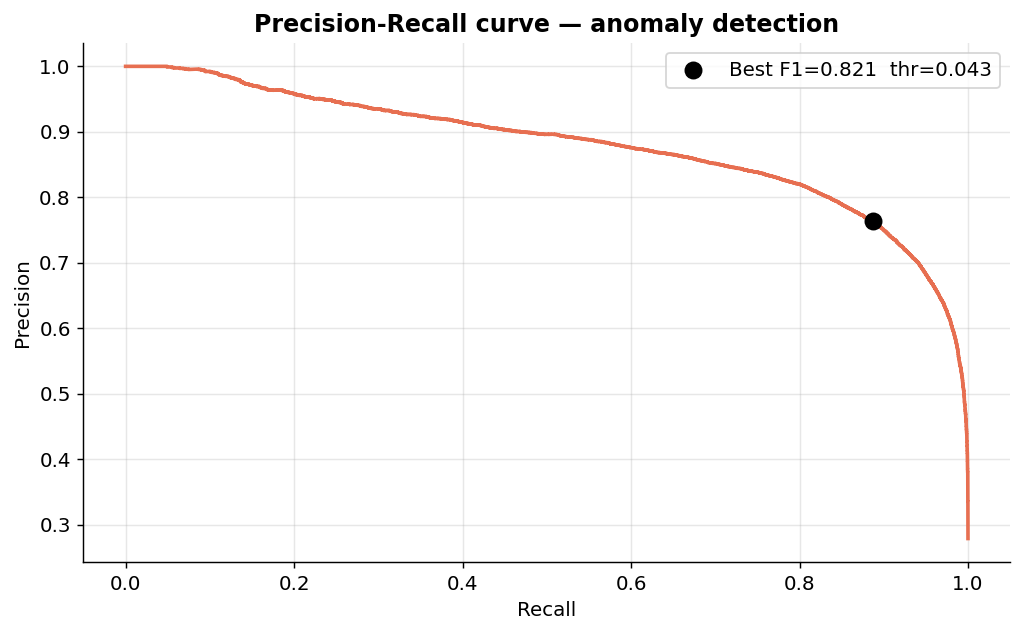

In [8]:
# Figure 2 — Precision-Recall curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, color='#e76f51', lw=2.0)
ax.scatter(rec[best_idx], prec[best_idx], color='black', zorder=5, s=80,
           label=f'Best F1={best_f1:.3f}  thr={best_thr:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve — anomaly detection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'anomaly_pr_curve.png')
plt.show()

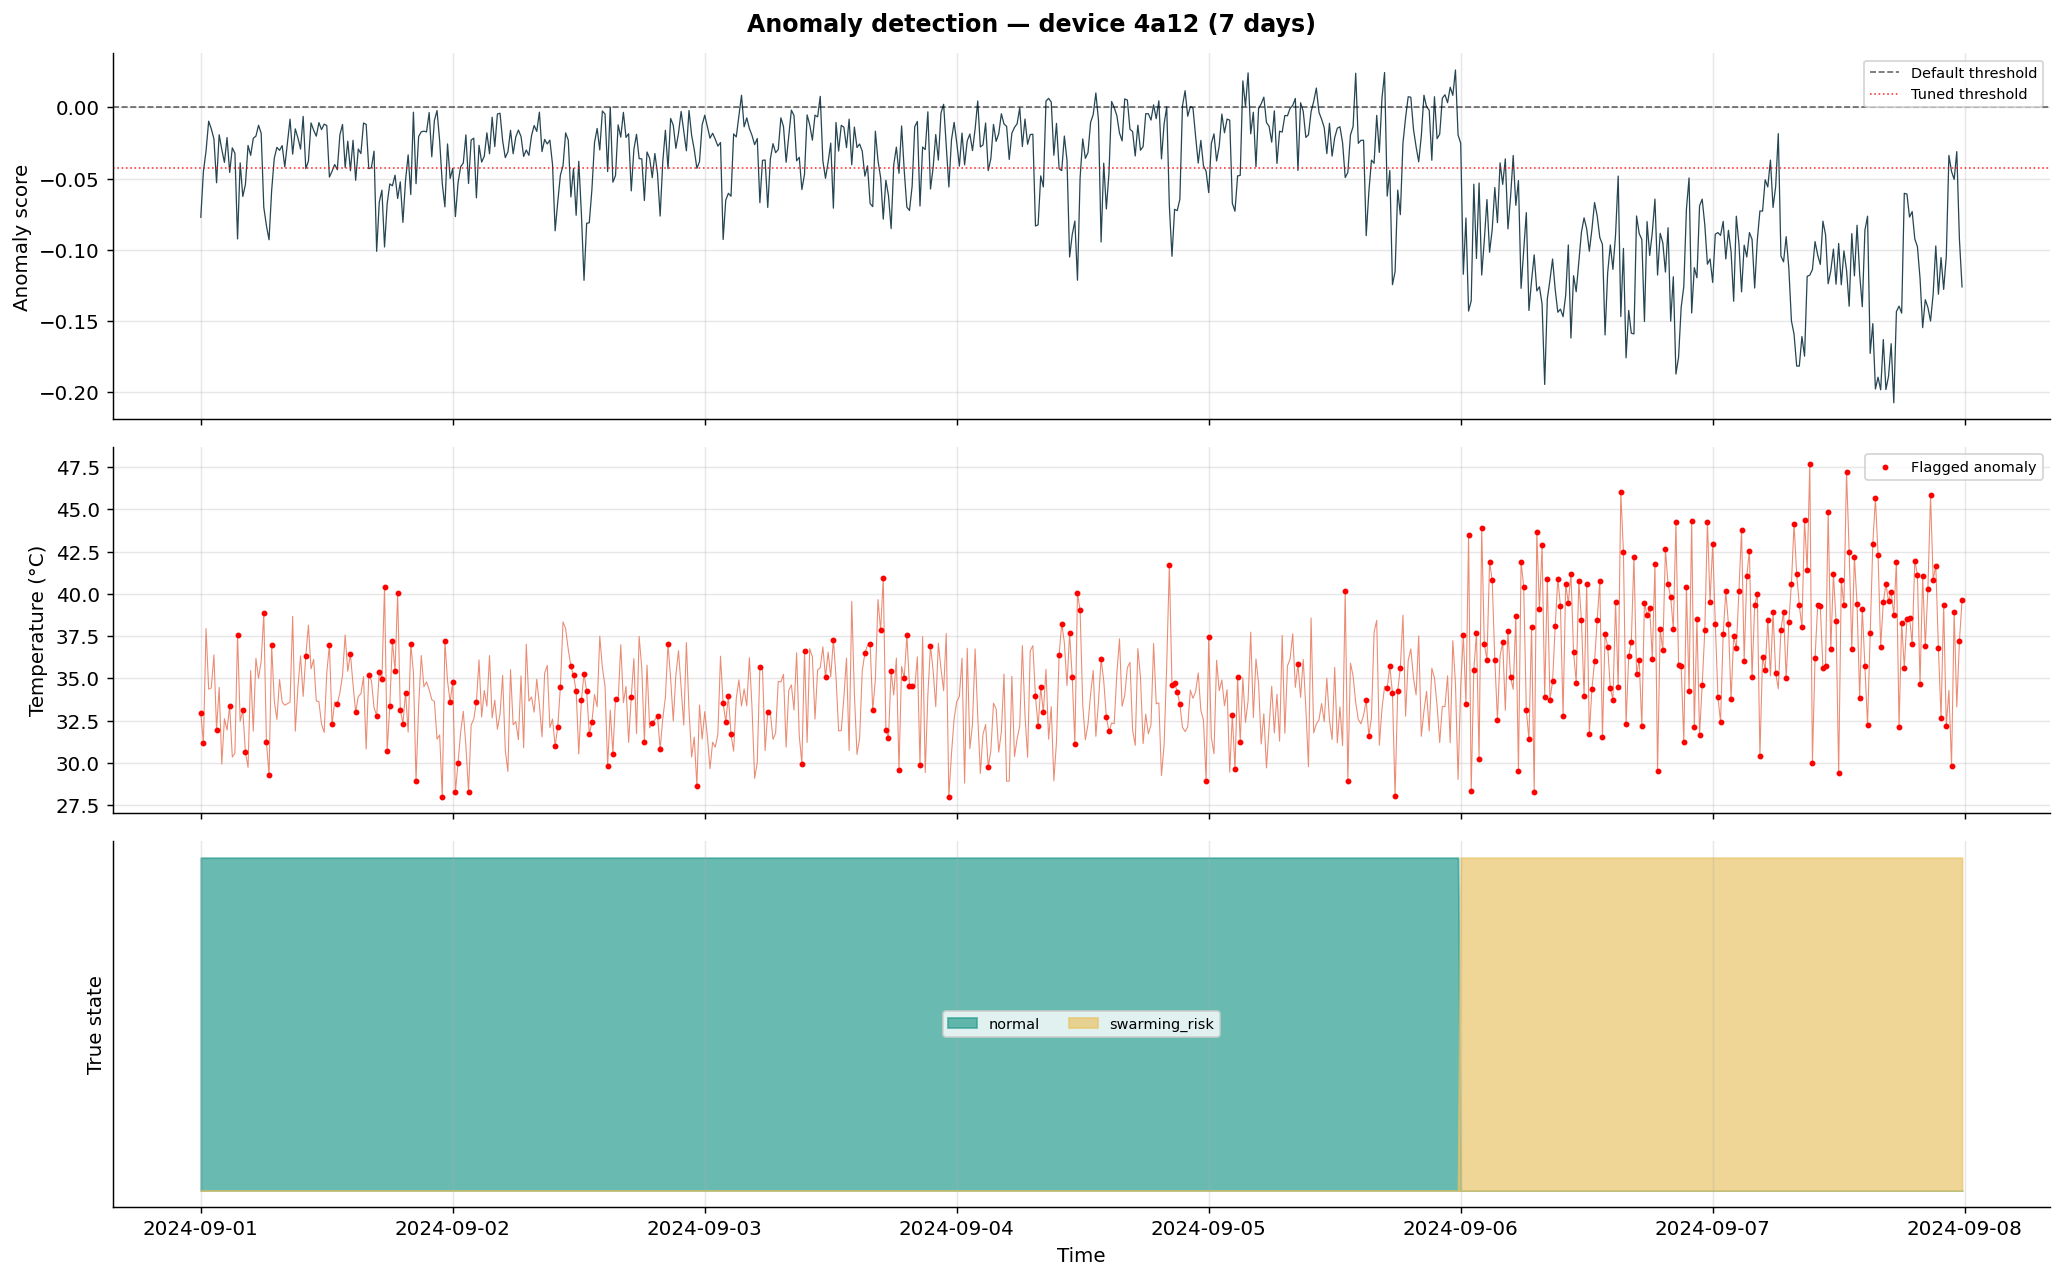

In [9]:
# Figure 3 — Anomaly score time series (one device, one week)
dev    = df['device_id'].iloc[0]
one_wk = df[(df['device_id'] == dev)].head(7 * 96)  # 7 days × 96 readings/day

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Anomaly detection — device {dev[-4:]} (7 days)', fontweight='bold')

# Anomaly score
axes[0].plot(one_wk['ts'], one_wk['anomaly_score'], lw=0.7, color='#264653')
axes[0].axhline(0,          color='black', lw=0.9, ls='--', alpha=0.6, label='Default threshold')
axes[0].axhline(-best_thr,  color='red',   lw=0.9, ls=':',  alpha=0.8, label='Tuned threshold')
axes[0].set_ylabel('Anomaly score')
axes[0].legend(fontsize=8)

# Temperature with anomaly markers
axes[1].plot(one_wk['ts'], one_wk['temperature_c'], lw=0.6, color='#e76f51', alpha=0.8)
anom = one_wk[one_wk['is_anomaly_tuned'] == 1]
axes[1].scatter(anom['ts'], anom['temperature_c'], color='red', s=5, zorder=5, label='Flagged anomaly')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend(fontsize=8)

# Ground truth state as color bands
for state, color in STATE_COLORS.items():
    mask = one_wk[TARGET] == state
    if mask.any():
        axes[2].fill_between(one_wk['ts'], 0, mask.astype(int), color=color, alpha=0.7, label=state)
axes[2].set_ylabel('True state')
axes[2].set_yticks([])
axes[2].legend(fontsize=8, ncol=3)
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'anomaly_timeseries.png')
plt.show()

## 7. Export enriched dataset + model

In [10]:
# Save enriched CSV — anomaly_score and is_anomaly feed into notebook 04
out_path = DATA_DIR / 'features_with_anomaly.csv'
df.to_csv(out_path, index=False)
print(f'✓ features_with_anomaly.csv  →  {out_path}')
print(f'  Shape    : {df.shape}')
print(f'  New cols : anomaly_score, is_anomaly, is_anomaly_tuned, is_anomaly_gt')

# Save model + scaler as a bundle
bundle = {
    'isolation_forest' : iso,
    'scaler'           : scaler,
    'features'         : FEATURES,
    'threshold'        : float(-best_thr),
    'contamination'    : contamination,
}
with open(MODELS_DIR / 'isolation_forest.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f'\n✓ isolation_forest.pkl      →  models/isolation_forest.pkl')

# Update features_meta.json with anomaly columns
meta['anomaly_features'] = ['anomaly_score', 'is_anomaly']
meta['anomaly_threshold'] = float(-best_thr)
(DATA_DIR / 'features_meta.json').write_text(json.dumps(meta, indent=2))
print(f'✓ features_meta.json updated')
print()
print('Next: run notebooks/04_classification.ipynb')

✓ features_with_anomaly.csv  →  ../data/processed/features_with_anomaly.csv
  Shape    : (350400, 34)
  New cols : anomaly_score, is_anomaly, is_anomaly_tuned, is_anomaly_gt

✓ isolation_forest.pkl      →  models/isolation_forest.pkl
✓ features_meta.json updated

Next: run notebooks/04_classification.ipynb
